In [34]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import scipy.stats as stats

In [35]:
os.getcwd()

'/Users/yilingyun/Documents/WorkInProgress/Charade/latent-force-model-project/human/behavioralExpDataAndAnalysis/exp3'

# Data Cleaning

In [4]:
subj = pd.read_csv("./raw/subj_HSvideo.txt", delimiter = "\t")
subj.head()

,num,date,startTime,id,userAgent,endTime,duration,quizAttemptN,instrReadingTimes,quickReadingPageN,...,hiddenDurations,comments,serious,maximized,problems,gender,age,inView,viewportW,viewportH
0,3,2026-02-09,23:05:14,66439abe4359251777b0aebd,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:18:36,13.358333,1,"{""0"":4.703,""1"":11.635,""2"":17.903,""3"":26.304,""4...",0,...,NaN,NaN,1,1,No issues and everything was clear.,F,25,True,1440,900
1,4,2026-02-09,23:07:18,62d43cee3d60ac98c1dcacc8,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:24:00,16.709167,1,"{""0"":3.278,""1"":21.902,""2"":25.63,""3"":32.079,""4""...",0,...,NaN,I do not have anything else that I would like ...,1,1,I did not find any part of the procedure to be...,M,28,True,1600,900
2,2,2026-02-09,23:04:09,5bf0b1ecaf38d100016bd609,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:24:57,20.793767,1,"{""0"":3.784,""1"":8.928,""2"":12.383,""3"":35.335,""4""...",0,...,NaN,"None, thank you",1,1,No issues. Thank you.,M,40,True,1920,1080
3,5,2026-02-09,23:14:19,69810933654afd25a7bbcf7d,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,23:26:54,12.592183,1,"{""0"":2.364,""1"":7.547,""2"":11.181,""3"":18.53,""4"":...",0,...,NaN,No,1,1,No,M,40,True,1440,900
4,7,2026-02-09,23:10:50,63b63938dbf229f3eb46d4a4,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,23:33:24,22.575867,1,"{""0"":599.836,""1"":602.325,""2"":606.346,""3"":610.6...",0,...,NaN,Best of luck to you in your research!,1,1,"It was all very clear, and I had no problems c...",M,53,True,1920,1080


In [5]:
len(subj)

51

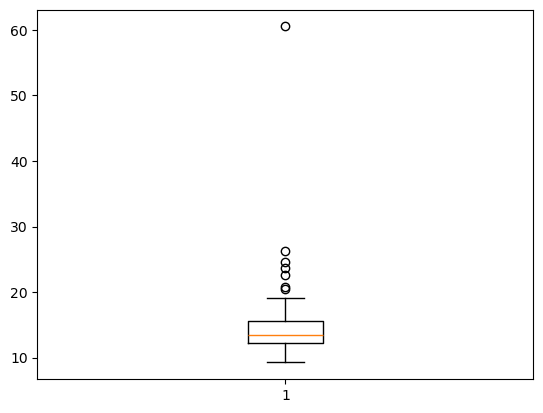

In [6]:
plt.boxplot(subj.duration)
plt.show()

In [7]:
subj.duration.median()

13.4771

In [8]:
subj.loc[subj.serious == 0, "num"]

Series([], Name: num, dtype: int64)

In [9]:
subj.loc[subj.maximized == 0, "num"]

Series([], Name: num, dtype: int64)

In [10]:
excludedSubjNum = list(pd.concat([subj.loc[subj.serious == 0, "num"], subj.loc[subj.maximized == 0, "num"]]))
excludedSubjNum

[]

## Normal speed trial file

In [11]:
trial = pd.read_csv("./raw/trial_HSvideo.txt", delimiter = ";")
trial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,2,2026-02-09,23:04:09,0,force_leave_1145_traj_5789,Leave,3,10.796,1
1,2,2026-02-09,23:04:09,1,force_accompany_5787_traj_4812,Bother,4,13.148,1
2,2,2026-02-09,23:04:09,2,force_capture_6035_traj_1051,Bother,4,12.840,1
3,2,2026-02-09,23:04:09,3,force_bother_6079_traj_5999,Fight,7,8.348,1
4,2,2026-02-09,23:04:09,4,force_scratch_6016_traj_1105,Accompany,1,10.121,1


In [12]:
trialN = 76
trial.shape[0]/trialN

52.0

In [13]:
trial.loc[trial.subjNum.isna()]

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts


In [14]:
# incomplete
incompleteSubjNum = trial.subjNum.value_counts().loc[lambda x : x < trialN].index
excludedSubjNum.extend(list(incompleteSubjNum))
incompleteSubjNum

Index([], dtype='int64', name='subjNum')

In [15]:
# subj file not saved
surveyIncompleteSubjNum = np.unique(trial.subjNum.loc[~trial.subjNum.isin(subj.num)])
excludedSubjNum.extend(list(surveyIncompleteSubjNum))
surveyIncompleteSubjNum

array([43])

In [16]:
completeTrial = trial[(~trial.subjNum.isin(incompleteSubjNum)) & (~trial.subjNum.isin(surveyIncompleteSubjNum))]
completeTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts
0,2,2026-02-09,23:04:09,0,force_leave_1145_traj_5789,Leave,3,10.796,1
1,2,2026-02-09,23:04:09,1,force_accompany_5787_traj_4812,Bother,4,13.148,1
2,2,2026-02-09,23:04:09,2,force_capture_6035_traj_1051,Bother,4,12.840,1
3,2,2026-02-09,23:04:09,3,force_bother_6079_traj_5999,Fight,7,8.348,1
4,2,2026-02-09,23:04:09,4,force_scratch_6016_traj_1105,Accompany,1,10.121,1


In [17]:
parts = completeTrial['exptId'].str.split('_', expand=True)
completeTrial = completeTrial.assign(
    type=parts[0],
    force=parts[1],
    traj=parts[4],
)

In [18]:
# exclude people who failed the filler trials
filler = completeTrial.loc[completeTrial.type == "filler"]
failedFiller = filler.loc[filler.label.str.lower() != filler.traj]
failedFiller

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts,type,force,traj
1043,13,2026-02-09,23:54:06,55,filler_pull_5809_response_fight,Encircle,2,15.651,3,filler,pull,fight


In [19]:
failedFillerSubj = np.unique(failedFiller.subjNum)
excludedSubjNum.extend(failedFillerSubj)

In [20]:
excludedSubjNum

[43, 13]

In [21]:
#drop not serious or not maximized
excSubjTrial = completeTrial[~completeTrial.subjNum.isin(excludedSubjNum)].copy()
excSubjTrial

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts,type,force,traj
0,2,2026-02-09,23:04:09,0,force_leave_1145_traj_5789,Leave,3,10.796,1,force,leave,5789
1,2,2026-02-09,23:04:09,1,force_accompany_5787_traj_4812,Bother,4,13.148,1,force,accompany,4812
2,2,2026-02-09,23:04:09,2,force_capture_6035_traj_1051,Bother,4,12.840,1,force,capture,1051
3,2,2026-02-09,23:04:09,3,force_bother_6079_traj_5999,Fight,7,8.348,1,force,bother,5999
4,2,2026-02-09,23:04:09,4,force_scratch_6016_traj_1105,Accompany,1,10.121,1,force,scratch,1105
...,...,...,...,...,...,...,...,...,...,...,...,...
3947,59,2026-02-11,00:42:09,71,force_encircle_6017_traj_6054,Encircle,2,6.070,1,force,encircle,6054
3948,59,2026-02-11,00:42:09,72,force_capture_6035_traj_4812,Accompany,1,5.563,1,force,capture,4812
3949,59,2026-02-11,00:42:09,73,force_hit_5902_traj_2029,Hit,0,6.299,1,force,hit,2029
3950,59,2026-02-11,00:42:09,74,force_leave_1145_traj_1051,Leave,6,4.034,1,force,leave,1051


In [22]:
cleanedTrial = excSubjTrial.loc[excSubjTrial.type != "filler"]

In [23]:
cleanedSubj = subj[~subj.num.isin(excludedSubjNum)]
n = len(cleanedSubj.num)
n

50

In [24]:
cleanedTrial = cleanedTrial.reset_index(drop = True)
cleanedTrial.to_csv(f"./{n}subj_cleaned_trial_HSvideo.csv", sep = "\t", index = False, header = True)
cleanedSubj.to_csv(f"{n}subj_cleaned_subj_HSvideo.csv", sep = "\t")

In [25]:
cleanedSubj.gender.value_counts()

gender
M    27
F    22
N     1
Name: count, dtype: int64

In [26]:
cleanedSubj.age.mean()

44.5

In [36]:
cleanedTrial = pd.read_csv(f"./50subj_cleaned_trial_HSvideo.csv", sep = "\t")
cleanedTrial.head()

,subjNum,subjStartDate,subjStartTime,trialIndex,exptId,label,labelIndex,rt,vidPlayCounts,type,force,traj
0,2,2026-02-09,23:04:09,0,force_leave_1145_traj_5789,Leave,3,10.796,1,force,leave,5789
1,2,2026-02-09,23:04:09,1,force_accompany_5787_traj_4812,Bother,4,13.148,1,force,accompany,4812
2,2,2026-02-09,23:04:09,2,force_capture_6035_traj_1051,Bother,4,12.840,1,force,capture,1051
3,2,2026-02-09,23:04:09,3,force_bother_6079_traj_5999,Fight,7,8.348,1,force,bother,5999
4,2,2026-02-09,23:04:09,4,force_scratch_6016_traj_1105,Accompany,1,10.121,1,force,scratch,1105


# Get distribution

In [37]:
cleanedTrial.type.value_counts()

type
force       3200
baseline     400
Name: count, dtype: int64

In [38]:
baseline = cleanedTrial.loc[cleanedTrial.type == "baseline"].copy()
baseline["response_aligned"] = baseline["label"].str.lower() == baseline["force"]

gen = cleanedTrial.loc[cleanedTrial.type == "force"].copy()
gen["response_aligned"] = gen["label"].str.lower() == gen["force"]

In [39]:
def get_summary(df):
    # 1) subject-level means within each force
    subj = (
        df.groupby(["subjNum", "force"])["response_aligned"]
        .mean()
        .reset_index()
    )

    # 2) CI across subjects, per force
    summary_subj = (
        subj.groupby("force")["response_aligned"]
                .agg(mean="mean", std="std", count="count")
    )

    summary_subj["sem"] = summary_subj["std"] / np.sqrt(summary_subj["count"])
    summary_subj["t_crit"] = stats.t.ppf(0.975, df=summary_subj["count"] - 1)
    summary_subj["ci_halfwidth"] = summary_subj["t_crit"] * summary_subj["sem"]

    return summary_subj

In [40]:
baseline_by_subj = get_summary(baseline)
gen_by_subj = get_summary(gen)

In [41]:
baseline_by_subj

,mean,std,count,sem,t_crit,ci_halfwidth
force,,,,,,
accompany,0.62,0.490314,50,0.069341,2.009575,0.139346
bother,0.16,0.370328,50,0.052372,2.009575,0.105246
capture,0.44,0.501427,50,0.070912,2.009575,0.142504
encircle,0.96,0.197949,50,0.027994,2.009575,0.056256
fight,0.38,0.490314,50,0.069341,2.009575,0.139346
hit,0.54,0.503457,50,0.071200,2.009575,0.143081
leave,0.98,0.141421,50,0.020000,2.009575,0.040192
scratch,0.34,0.478518,50,0.067673,2.009575,0.135993


In [42]:
# sort by generated animation mean
force_order = gen_by_subj["mean"].sort_values(ascending=False).index

df_plot = pd.DataFrame({
    "Baseline": baseline_by_subj.loc[force_order, "mean"],
    "Baseline CI": baseline_by_subj.loc[force_order, "ci_halfwidth"],
    "Gen mean": gen_by_subj.loc[force_order, "mean"],
    "Gen CI": gen_by_subj.loc[force_order, "ci_halfwidth"],
})

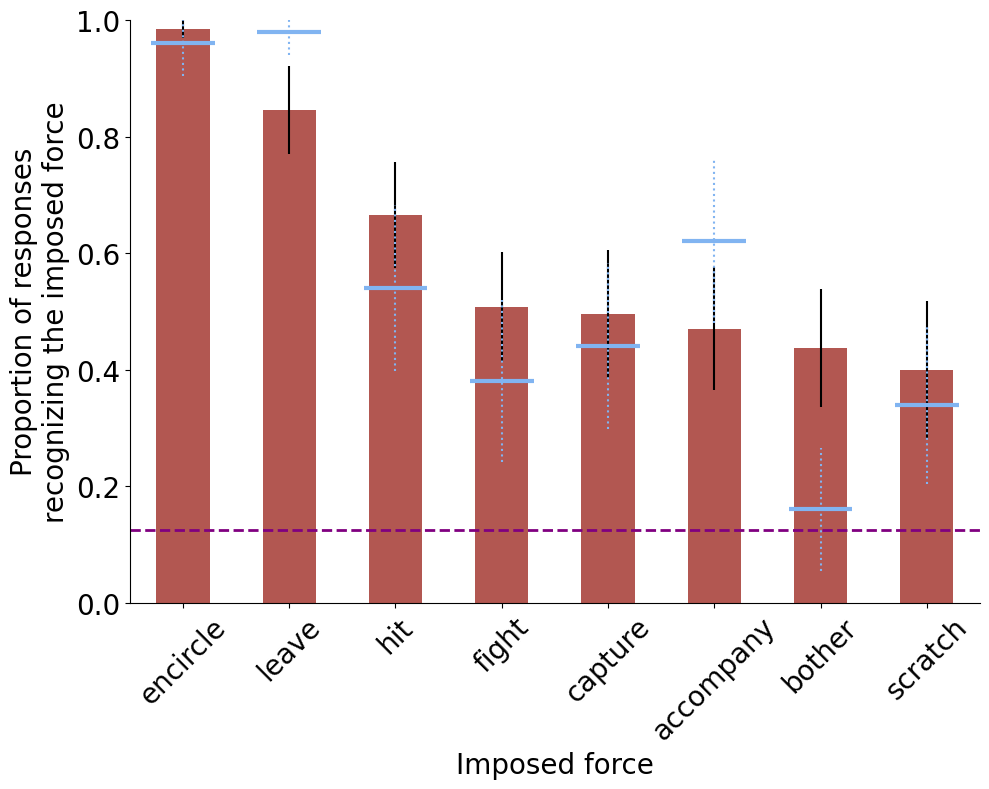

In [43]:
f, ax = plt.subplots(figsize=(10, 8))

df_plot["Gen mean"].plot.bar(
    rot=45,
    figsize=(10, 8),
    yerr = df_plot["Gen CI"],
    color="#b25751"     # generated color (red-ish)
)

# Add baseline as short horizontal line segments
x = np.arange(len(df_plot.index))
baseline_vals = df_plot["Baseline"].values
line_half = 0.3  # width of horizontal tick

for xi, b, ci in zip(x, baseline_vals, df_plot["Baseline CI"]):
    # Horizontal baseline tick
    ax.hlines(
        y=b,
        xmin=xi - line_half,
        xmax=xi + line_half,
        colors="#81b4f1",
        linewidth=3
    )

    # Vertical error bar
    ax.vlines(
        x=xi,
        ymin=b - ci,
        ymax=b + ci,
        linestyles="dotted",
        colors="#81b4f1"
    )

plt.tick_params(axis="both", labelsize=20)
ax.set_ylabel("Proportion of responses\nrecognizing the imposed force", fontsize=20)
ax.set_xlabel("Imposed force", fontsize=20)
# Chance line
ax.axhline(y=1/8, color='purple', linestyle='--', linewidth=2, label='Chance (1/8)')
ax.set_ylim([0, 1])

# plt.title("Baseline vs. Generated Force Video Impressions")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()
f.savefig('study3_bar.png', bbox_inches='tight', dpi = 300)


# Statistical analysis

## gen vs chance

### analysis by subject

In [50]:
gen_video_proportions_by_subj = gen.groupby(["force", "subjNum"])["response_aligned"].mean().loc[force_order].reset_index()
gen_video_proportions_by_subj

,force,subjNum,response_aligned
0,encircle,2,1.000
1,encircle,3,1.000
2,encircle,4,0.875
3,encircle,5,1.000
4,encircle,7,1.000
...,...,...,...
395,scratch,55,0.625
396,scratch,56,0.125
397,scratch,57,0.875
398,scratch,58,0.125


In [51]:
chance = 1 / 8
results_by_subj = []

for force in gen_video_proportions_by_subj["force"].unique():
    proportions = gen_video_proportions_by_subj[gen_video_proportions_by_subj["force"] == force]["response_aligned"]
    t, p = stats.ttest_1samp(proportions, popmean=chance, alternative="two-sided")
    results_by_subj.append({
        "force": force,
        "mean_proportion": proportions.mean(),
        "t_stat": t,
        "p_value": p
    })
pd.DataFrame(results_by_subj)

,force,mean_proportion,t_stat,p_value
0,encircle,0.9850,111.788594,1.127536e-60
1,leave,0.8450,19.086939,2.465489e-24
2,hit,0.6650,11.899980,4.597419e-16
3,fight,0.5075,8.086532,1.409295e-10
4,capture,0.4950,6.787644,1.415115e-08
5,accompany,0.4700,6.549190,3.313870e-08
6,bother,0.4375,6.214432,1.092507e-07
7,scratch,0.4000,4.703524,2.120970e-05


### analysis by item

In [48]:
gen_video_proportions_by_item = gen.groupby(["force", "exptId"])["response_aligned"].mean().loc[force_order].reset_index()
gen_video_proportions_by_item

,force,exptId,response_aligned
0,encircle,force_encircle_6017_traj_1051,0.958333
1,encircle,force_encircle_6017_traj_1105,1.000000
2,encircle,force_encircle_6017_traj_2029,1.000000
3,encircle,force_encircle_6017_traj_4812,1.000000
4,encircle,force_encircle_6017_traj_5098,0.946429
...,...,...,...
59,scratch,force_scratch_6016_traj_4812,0.562500
60,scratch,force_scratch_6016_traj_5098,0.725000
61,scratch,force_scratch_6016_traj_5789,0.546875
62,scratch,force_scratch_6016_traj_5999,0.250000


In [49]:
chance = 1 / 8
results_by_item = []

for force in gen_video_proportions_by_item["force"].unique():
    proportions = gen_video_proportions_by_item[gen_video_proportions_by_item["force"] == force]["response_aligned"]
    t, p = stats.ttest_1samp(proportions, popmean=chance, alternative="two-sided")
    results_by_item.append({
        "force": force,
        "mean_proportion": proportions.mean(),
        "t_stat": t,
        "p_value": p
    })
pd.DataFrame(results_by_item)

,force,mean_proportion,t_stat,p_value
0,encircle,0.985491,111.155686,1.257443e-12
1,leave,0.817333,14.554586,1.725186e-06
2,hit,0.684592,8.173425,7.946404e-05
3,fight,0.533996,7.751292,1.114519e-04
4,capture,0.456062,3.137172,1.644402e-02
5,accompany,0.486607,4.657600,2.321042e-03
6,bother,0.433270,4.647328,2.349246e-03
7,scratch,0.390321,3.444933,1.076496e-02


## ANOVA prep (analysis in R)

In [40]:
# Combine baseline + gen back into one df (if not already)
df = pd.concat([baseline, gen], ignore_index=True)
df["type"] = df["type"].replace({"baseline": "baseline", "force": "generated"})

# Subject-level means 
subj_means = (
    df.groupby(["subjNum", "type", "force"], as_index=False)["response_aligned"]
      .mean()
)
# Ensure types are strings (R likes factors)
subj_means["subjNum"] = subj_means["subjNum"].astype(str)
subj_means["type"] = subj_means["type"].astype(str)
subj_means["force"] = subj_means["force"].astype(str)

# Save
subj_means.to_csv("response_aligned_by_subj.csv", index=False)
subj_means.head()

,subjNum,type,force,response_aligned
0,2,baseline,accompany,0.0
1,2,baseline,bother,0.0
2,2,baseline,capture,1.0
3,2,baseline,encircle,1.0
4,2,baseline,fight,0.0
